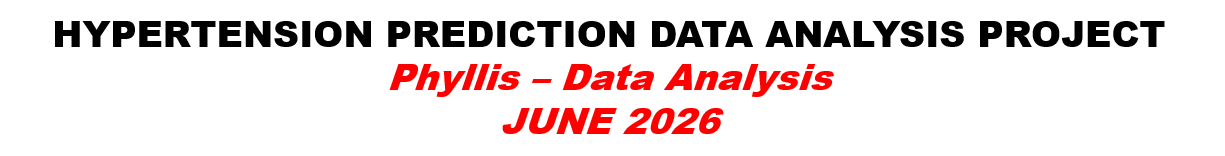
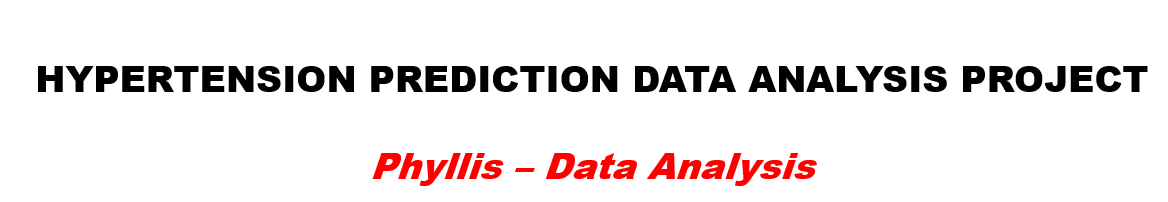
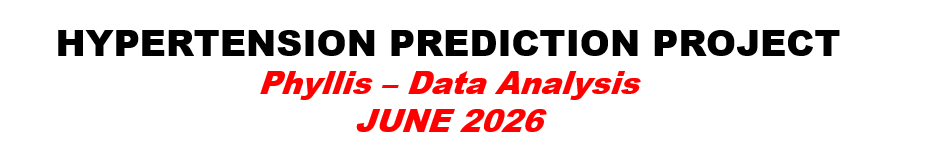
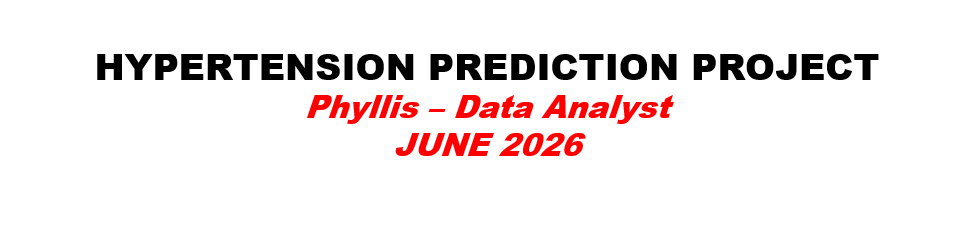

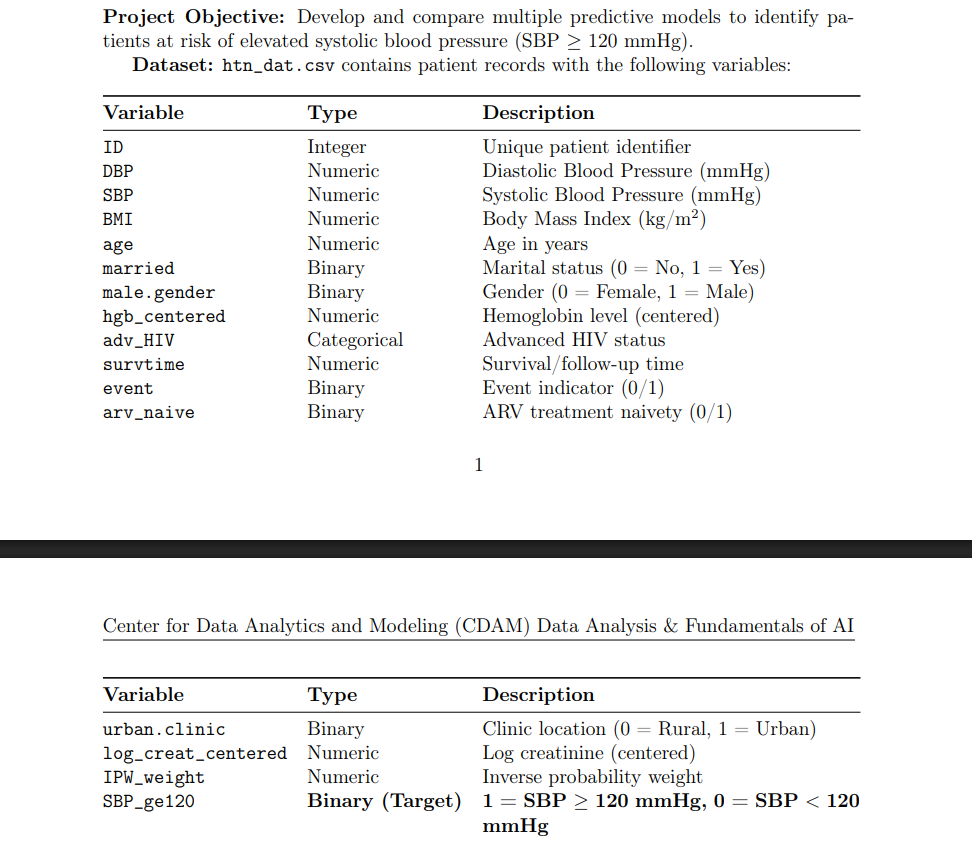

## Loading the required libraries

# C1. DATA UNDERSTANDING AND PREPARATION


In [140]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve, confusion_matrix,
                             classification_report)
import warnings
warnings.filterwarnings('ignore')

# 2.Data Importation

In [141]:
df = pd.read_csv("htn_dat.csv")
df.head()

,ID,DBP,SBP,BMI,age,married,male.gender,hgb_centered,adv_HIV,survtime,event,arv_naive,urban.clinic,log_creat_centered,IPW_weight,SBP_ge120
0,16097,60,90,NaN,28.000000,0.0,0,NaN,NaN,338,1,1,0,NaN,0.924379,0
1,930,75,110,27.339912,26.458590,1.0,0,-3.9,0.0,439,1,1,1,5.421770e-02,1.163862,0
2,6877,60,80,17.689789,42.951405,0.0,0,-3.2,NaN,752,1,1,0,-3.597409e-01,0.721148,0
3,36464,60,90,19.854080,50.149212,1.0,1,NaN,NaN,526,1,1,1,NaN,0.829452,0
4,36180,60,100,21.295294,30.554415,0.0,1,-0.4,NaN,215,1,1,0,-1.000000e-07,0.856046,0


In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  4999 non-null   int64  
 1   DBP                 4999 non-null   int64  
 2   SBP                 4999 non-null   int64  
 3   BMI                 4329 non-null   float64
 4   age                 4999 non-null   float64
 5   married             4835 non-null   float64
 6   male.gender         4999 non-null   int64  
 7   hgb_centered        3605 non-null   float64
 8   adv_HIV             3038 non-null   float64
 9   survtime            4999 non-null   int64  
 10  event               4999 non-null   int64  
 11  arv_naive           4999 non-null   int64  
 12  urban.clinic        4999 non-null   int64  
 13  log_creat_centered  3461 non-null   float64
 14  IPW_weight          4999 non-null   float64
 15  SBP_ge120           4999 non-null   int64  
dtypes: flo

In [143]:
df.shape

(4999, 16)

In [144]:
df.describe()

,ID,DBP,SBP,BMI,age,married,male.gender,hgb_centered,adv_HIV,survtime,event,arv_naive,urban.clinic,log_creat_centered,IPW_weight,SBP_ge120
count,4999.000000,4999.000000,4999.000000,4329.000000,4999.000000,4835.000000,4999.000000,3605.000000,3038.000000,4999.000000,4999.000000,4999.000000,4999.000000,3461.000000,4999.000000,4999.000000
mean,24972.219644,68.030206,110.593919,21.428649,35.191304,0.589038,0.271054,-0.054466,0.628045,750.529506,0.150030,0.906381,0.472494,-0.090452,0.995007,0.050010
std,14379.942003,10.319607,14.776308,3.619755,10.563761,0.492059,0.444548,2.590723,0.483406,650.878636,0.357137,0.291327,0.499293,0.315698,0.325378,0.217987
min,6.000000,40.000000,65.000000,15.002075,16.024641,0.000000,0.000000,-10.600000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.825464,0.521930,0.000000
25%,12466.500000,60.000000,100.000000,18.870663,27.197809,0.000000,0.000000,-1.600000,0.000000,178.500000,0.000000,1.000000,0.000000,-0.278203,0.839650,0.000000
50%,25464.000000,70.000000,110.000000,20.835959,33.470226,1.000000,0.000000,0.100000,1.000000,589.000000,0.000000,1.000000,0.000000,-0.096354,0.955120,0.000000
75%,37626.500000,73.000000,120.000000,23.272667,41.582478,1.000000,1.000000,1.600000,1.000000,1221.500000,0.000000,1.000000,1.000000,0.088795,1.129092,0.000000
max,49474.000000,120.000000,210.000000,39.437584,79.630386,1.000000,1.000000,35.200001,1.000000,2383.000000,1.000000,1.000000,1.000000,2.321967,5.378972,1.000000


## 3. Data Cleaning
### Check for missing Values

In [145]:
df.isnull().sum()

ID                       0
DBP                      0
SBP                      0
BMI                    670
age                      0
married                164
male.gender              0
hgb_centered          1394
adv_HIV               1961
survtime                 0
event                    0
arv_naive                0
urban.clinic             0
log_creat_centered    1538
IPW_weight               0
SBP_ge120                0
dtype: int64

In [146]:
## Extract Target Variables
# Create the new target variable: Hypertension (SBP >= 120 OR DBP >= 90)
df['hypertension'] = np.where((df['SBP'] >= 120) | (df['DBP'] >= 90), 1, 0)

In [147]:
print("\nTarget Variable Distribution (Hypertension):")
print(df['hypertension'].value_counts())


Target Variable Distribution (Hypertension):
hypertension
0    3288
1    1711
Name: count, dtype: int64


<Figure size 1600x1200 with 0 Axes>

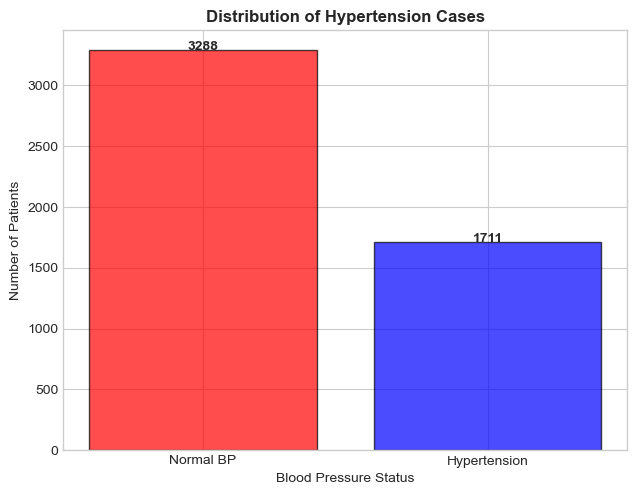

In [148]:
# 1. Target Class Distribution Plot
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 12))
plt.subplot(2, 2, 1)
hypertension_counts = df['hypertension'].value_counts()
plt.bar(['Normal BP', 'Hypertension'], hypertension_counts, 
        color=['red', 'blue'], edgecolor='black', alpha=0.7)
plt.title('Distribution of Hypertension Cases', fontsize=12, fontweight='bold')
plt.ylabel('Number of Patients')
plt.xlabel('Blood Pressure Status')
for i, v in enumerate(hypertension_counts):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')

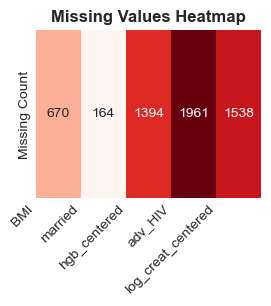

In [149]:
# 2. Missing Value Heatmap
plt.subplot(2, 2, 2)
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_data, 
                           'Missing Percentage': missing_percentage})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) > 0:
    sns.heatmap(missing_df[['Missing Count']].T, cmap='Reds', annot=True, 
                fmt='.0f', cbar=False)
    plt.title('Missing Values Heatmap', fontsize=12, fontweight='bold')
    plt.xticks(range(len(missing_df.index)), missing_df.index, rotation=45, ha='right')
else:
    plt.text(0.5, 0.5, 'No Missing Values', ha='center', va='center', 
             fontsize=14, fontweight='bold')
    plt.title('Missing Values Heatmap', fontsize=12, fontweight='bold')

([<matplotlib.axis.XTick at 0x2a48d0af610>,
 [Text(1, 0, 'age'), Text(2, 0, 'BMI'), Text(3, 0, 'SBP'), Text(4, 0, 'DBP')])

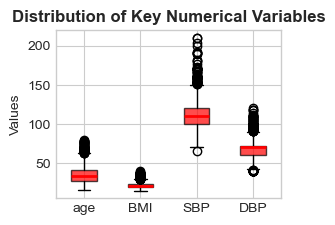

In [150]:
# 3. Numerical Feature Distributions (Boxplots)
plt.subplot(2, 2, 3)
numerical_cols = ['age', 'BMI', 'SBP', 'DBP']
df_box = df[numerical_cols].dropna()
bp = plt.boxplot(df_box.values, labels=numerical_cols, patch_artist=True,
                 boxprops=dict(facecolor='red', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2))
plt.title('Distribution of Key Numerical Variables', fontsize=12, fontweight='bold')
plt.ylabel('Values')
plt.xticks(range(1, len(numerical_cols) + 1), numerical_cols)

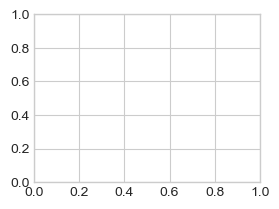

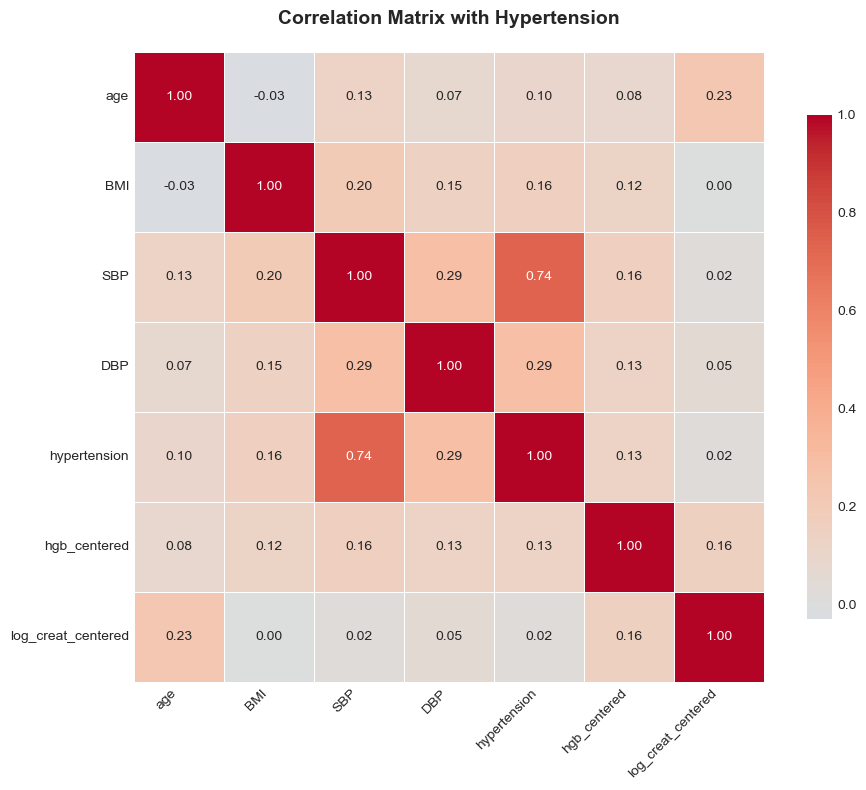

In [151]:
# 4. Correlation Matrix Heatmap - LARGER SIZE
plt.subplot(2, 2, 4)
# Select numerical columns for correlation
corr_cols = ['age', 'BMI', 'SBP', 'DBP', 'hypertension', 'hgb_centered', 
             'log_creat_centered']
corr_df = df[corr_cols].dropna()
corr_matrix = corr_df.corr()

# Create larger heatmap with bigger figure
plt.figure(figsize=(10, 8))  # Larger figure size
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, linewidths=0.5,
            annot_kws={"size": 10},  # Increase annotation font size
            cbar_kws={"shrink": 0.8})  # Adjust colorbar size
plt.title('Correlation Matrix with Hypertension', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)  # Rotate and enlarge x-axis labels
plt.yticks(fontsize=10)  # Enlarge y-axis labels
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [152]:
# Additional interpretation
print("\n" + "=" * 60)
print("KEY OBSERVATIONS FROM EXPLORATORY ANALYSIS")
print("=" * 60)
print(f"\n1. Target Distribution:")
print(f"   - Normal BP: {hypertension_counts.get(0, 0)} patients")
print(f"   - Hypertension: {hypertension_counts.get(1, 0)} patients")

print(f"\n2. Missing Values:")
print(missing_df if len(missing_df) > 0 else "   No missing values detected")

print(f"\n3. Correlation with Hypertension:")
hypertension_corr = corr_matrix['hypertension'].drop('hypertension').sort_values(ascending=False)
for col, corr in hypertension_corr.items():
    print(f"   - {col}: {corr:.3f}")


KEY OBSERVATIONS FROM EXPLORATORY ANALYSIS

1. Target Distribution:
   - Normal BP: 3288 patients
   - Hypertension: 1711 patients

2. Missing Values:
                    Missing Count  Missing Percentage
BMI                           670           13.402681
married                       164            3.280656
hgb_centered                 1394           27.885577
adv_HIV                      1961           39.227846
log_creat_centered           1538           30.766153

3. Correlation with Hypertension:
   - SBP: 0.737
   - DBP: 0.285
   - BMI: 0.161
   - hgb_centered: 0.132
   - age: 0.099
   - log_creat_centered: 0.024


# C1(b)(i) Calculate class distribution and imbalance ratio

In [153]:
print("\n" + "=" * 60)
print("C1(b)(i) CLASS DISTRIBUTION AND IMBALANCE RATIO")
print("=" * 60)

class_counts = df['hypertension'].value_counts().sort_index()
total_samples = len(df)

print(f"\nClass Distribution:")
print(f"Class 0 (Normal BP): {class_counts[0]} ({class_counts[0]/total_samples*100:.2f}%)")
print(f"Class 1 (Hypertension): {class_counts[1]} ({class_counts[1]/total_samples*100:.2f}%)")

imbalance_ratio = class_counts[0] / class_counts[1] if class_counts[1] > 0 else 0
print(f"\nImbalance Ratio (Class 0 : Class 1): {imbalance_ratio:.2f}:1")


C1(b)(i) CLASS DISTRIBUTION AND IMBALANCE RATIO

Class Distribution:
Class 0 (Normal BP): 3288 (65.77%)
Class 1 (Hypertension): 1711 (34.23%)

Imbalance Ratio (Class 0 : Class 1): 1.92:1


# WHY CLASS IMBALANCE MATTERS:

1. **Model Bias**: Machine learning models tend to be biased towards the 
   majority class, potentially leading to poor prediction of the minority class.

2. **Misleading Accuracy**: A model could achieve high accuracy by simply 
   predicting the majority class, but fail to identify hypertension cases 
   (which is clinically critical).

3. **Metric Selection**: Accuracy alone is insufficient. We need metrics like:
   - **Recall/Sensitivity**: Critical for identifying true hypertension cases
   - **Precision**: Important to avoid false alarms
   - **F1-Score**: Balance between precision and recall
   - **ROC-AUC**: Overall discriminative ability
   - **Specificity**: Correctly identifying normal BP patients

4. **Clinical Relevance**: Missing a hypertension case (false negative) could 
   lead to untreated high blood pressure and increased risk of heart attack, 
   stroke, or kidney disease.


# C1(b)(ii) Handle missing values


In [154]:
# Identify columns with missing values
missing_before = df.isnull().sum()
print("\nMissing values before imputation:")
print(missing_before[missing_before > 0])


Missing values before imputation:
BMI                    670
married                164
hgb_centered          1394
adv_HIV               1961
log_creat_centered    1538
dtype: int64


In [155]:
# Separate features and target
# Define predictor variables (X) that may result in risk of hypertension/heart attack
predictor_cols = ['age', 'BMI', 'DBP', 'married', 'male.gender', 'hgb_centered',
                  'adv_HIV', 'survtime', 'event', 'arv_naive', 'urban.clinic',
                  'log_creat_centered', 'IPW_weight']


In [156]:
df_processed = df[predictor_cols + ['hypertension']].copy()
df_processed.head()

,age,BMI,DBP,married,male.gender,hgb_centered,adv_HIV,survtime,event,arv_naive,urban.clinic,log_creat_centered,IPW_weight,hypertension
0,28.000000,NaN,60,0.0,0,NaN,NaN,338,1,1,0,NaN,0.924379,0
1,26.458590,27.339912,75,1.0,0,-3.9,0.0,439,1,1,1,5.421770e-02,1.163862,0
2,42.951405,17.689789,60,0.0,0,-3.2,NaN,752,1,1,0,-3.597409e-01,0.721148,0
3,50.149212,19.854080,60,1.0,1,NaN,NaN,526,1,1,1,NaN,0.829452,0
4,30.554415,21.295294,60,0.0,1,-0.4,NaN,215,1,1,0,-1.000000e-07,0.856046,0


In [157]:
# Separate numerical and categorical columns
numerical_cols = ['age', 'BMI', 'DBP', 'hgb_centered', 'survtime', 
                  'log_creat_centered', 'IPW_weight']
categorical_cols = ['married', 'male.gender', 'adv_HIV', 'event', 
                    'arv_naive', 'urban.clinic']

In [158]:
# C1(b)(ii) - HANDLING MISSING VALUES"

# Check missing values before imputation
print("\nMissing values before imputation:")
print(df.isnull().sum())


Missing values before imputation:
ID                       0
DBP                      0
SBP                      0
BMI                    670
age                      0
married                164
male.gender              0
hgb_centered          1394
adv_HIV               1961
survtime                 0
event                    0
arv_naive                0
urban.clinic             0
log_creat_centered    1538
IPW_weight               0
SBP_ge120                0
hypertension             0
dtype: int64


In [159]:

# Create a copy of the dataframe for processing
df_processed = df.copy()
df_processed.head()

,ID,DBP,SBP,BMI,age,married,male.gender,hgb_centered,adv_HIV,survtime,event,arv_naive,urban.clinic,log_creat_centered,IPW_weight,SBP_ge120,hypertension
0,16097,60,90,NaN,28.000000,0.0,0,NaN,NaN,338,1,1,0,NaN,0.924379,0,0
1,930,75,110,27.339912,26.458590,1.0,0,-3.9,0.0,439,1,1,1,5.421770e-02,1.163862,0,0
2,6877,60,80,17.689789,42.951405,0.0,0,-3.2,NaN,752,1,1,0,-3.597409e-01,0.721148,0,0
3,36464,60,90,19.854080,50.149212,1.0,1,NaN,NaN,526,1,1,1,NaN,0.829452,0,0
4,36180,60,100,21.295294,30.554415,0.0,1,-0.4,NaN,215,1,1,0,-1.000000e-07,0.856046,0,0


In [160]:
# Impute missing values
# For numerical: Use median (robust to outliers, common in medical data)
# For categorical: Use mode (most frequent value)

print("\nImputation Strategy:")
print("-" * 60)
print("Numerical columns: Median imputation")
print("  - Justification: Medical data often contains outliers.")
print("  - Median is robust and preserves the central tendency.")
print("  - More appropriate than mean for skewed distributions.")
print("\nCategorical columns: Mode imputation")
print("  - Justification: Preserves the most common category.")
print("  - Appropriate for binary/categorical clinical variables.")



Imputation Strategy:
------------------------------------------------------------
Numerical columns: Median imputation
  - Justification: Medical data often contains outliers.
  - Median is robust and preserves the central tendency.
  - More appropriate than mean for skewed distributions.

Categorical columns: Mode imputation
  - Justification: Preserves the most common category.
  - Appropriate for binary/categorical clinical variables.


In [161]:
# Apply imputation
numerical_imputer = SimpleImputer(strategy='median')
categorical_imputer = SimpleImputer(strategy='most_frequent')

df_processed[numerical_cols] = numerical_imputer.fit_transform(df_processed[numerical_cols])
df_processed[categorical_cols] = categorical_imputer.fit_transform(df_processed[categorical_cols])

# Verify imputation
missing_after = df_processed.isnull().sum()
print("\nMissing values after imputation:")
print(missing_after[missing_after > 0] if missing_after.sum() > 0 else "No missing values remaining")


Missing values after imputation:
No missing values remaining


In [162]:
# Checking if there is still missing values
print("\nMissing values after imputation:")
print(df_processed.isnull().sum())


Missing values after imputation:
ID                    0
DBP                   0
SBP                   0
BMI                   0
age                   0
married               0
male.gender           0
hgb_centered          0
adv_HIV               0
survtime              0
event                 0
arv_naive             0
urban.clinic          0
log_creat_centered    0
IPW_weight            0
SBP_ge120             0
hypertension          0
dtype: int64


# C1(b)(iii) Encode categorical/binary variables

In [163]:
# Check current data types
print("\nData types before encoding:")
print(df_processed.dtypes)


Data types before encoding:
ID                      int64
DBP                   float64
SBP                     int64
BMI                   float64
age                   float64
married               float64
male.gender           float64
hgb_centered          float64
adv_HIV               float64
survtime              float64
event                 float64
arv_naive             float64
urban.clinic          float64
log_creat_centered    float64
IPW_weight            float64
SBP_ge120               int64
hypertension            int64
dtype: object


In [164]:
# All categorical variables are already binary (0/1), so they're compatible
# But let's verify and ensure they're properly encoded
binary_vars = ['married', 'male.gender', 'adv_HIV', 'event', 'arv_naive', 'urban.clinic']

print("\nBinary variables verification:")
for var in binary_vars:
    unique_vals = df_processed[var].unique()
    print(f"{var}: {unique_vals}")


Binary variables verification:
married: [0. 1.]
male.gender: [0. 1.]
adv_HIV: [1. 0.]
event: [1. 0.]
arv_naive: [1. 0.]
urban.clinic: [0. 1.]


In [165]:
# If there are any categorical variables with more than 2 categories, use LabelEncoder
# For this dataset, variables appear to be already binary encoded
print("\nNote: All categorical variables are already binary encoded (0/1)")
print("No additional encoding required for scikit-learn compatibility.")


Note: All categorical variables are already binary encoded (0/1)
No additional encoding required for scikit-learn compatibility.


# Preparing final X and y

In [166]:
X = df_processed[predictor_cols].copy()
y = df_processed['hypertension'].copy()

print("\n" + "=" * 60)
print("FINAL DATASET PREPARATION")
print("=" * 60)
print(f"\nFeature matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")
print(f"\nFeatures (X variables for hypertension/heart attack risk):")
for i, col in enumerate(predictor_cols, 1):
    print(f"{i}. {col}")

print("\nClinical relevance of selected predictors:")
print("-" * 60)
print("1. age: Older age increases cardiovascular risk")
print("2. BMI: Higher BMI associated with hypertension and heart disease")
print("3. DBP: Diastolic BP is a direct indicator of hypertension")
print("4. married: Marital status may affect stress and health behaviors")
print("5. male.gender: Men have different cardiovascular risk profiles")
print("6. hgb_centered: Hemoglobin levels affect oxygen transport")
print("7. adv_HIV: Advanced HIV status impacts cardiovascular health")
print("8. survtime: Follow-up time for longitudinal assessment")
print("9. event: Previous cardiovascular events")
print("10. arv_naive: ARV treatment status affects metabolic health")
print("11. urban.clinic: Location affects access to care and lifestyle")
print("12. log_creat_centered: Kidney function marker")
print("13. IPW_weight: Statistical weight for causal inference")


FINAL DATASET PREPARATION

Feature matrix X shape: (4999, 13)
Target vector y shape: (4999,)

Features (X variables for hypertension/heart attack risk):
1. age
2. BMI
3. DBP
4. married
5. male.gender
6. hgb_centered
7. adv_HIV
8. survtime
9. event
10. arv_naive
11. urban.clinic
12. log_creat_centered
13. IPW_weight

Clinical relevance of selected predictors:
------------------------------------------------------------
1. age: Older age increases cardiovascular risk
2. BMI: Higher BMI associated with hypertension and heart disease
3. DBP: Diastolic BP is a direct indicator of hypertension
4. married: Marital status may affect stress and health behaviors
5. male.gender: Men have different cardiovascular risk profiles
6. hgb_centered: Hemoglobin levels affect oxygen transport
7. adv_HIV: Advanced HIV status impacts cardiovascular health
8. survtime: Follow-up time for longitudinal assessment
9. event: Previous cardiovascular events
10. arv_naive: ARV treatment status affects metabolic he

In [167]:
# Save processed data for later use
df_processed.to_csv('htn_dat_processed.csv', index=False)
print("\nProcessed data saved to 'htn_dat_processed.csv'")


Processed data saved to 'htn_dat_processed.csv'


# **C2. Model Development Strategy**
## C2(a) Split data into training and testing sets

In [194]:
print("\n" + "=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

# Split parameters
TEST_SIZE = 0.30  # 70:30 split
STRATIFY = y
RANDOM_STATE = 42

print(f"\nSplit Configuration:")
print(f"  - Training set: {(1-TEST_SIZE)*100:.0f}%")
print(f"  - Testing set: {TEST_SIZE*100:.0f}%")
print(f"  - Stratified sampling: Yes (preserves class distribution)")
print(f"  - Random state: {RANDOM_STATE} (for reproducibility)")


TRAIN-TEST SPLIT

Split Configuration:
  - Training set: 70%
  - Testing set: 30%
  - Stratified sampling: Yes (preserves class distribution)
  - Random state: 42 (for reproducibility)


In [169]:
# Perform stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    stratify=STRATIFY, 
    random_state=RANDOM_STATE
)

print(f"\nDataset Shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  y_test: {y_test.shape}")


Dataset Shapes:
  X_train: (3499, 13)
  X_test: (1500, 13)
  y_train: (3499,)
  y_test: (1500,)


In [170]:
# Verifying class distribution preservation
print(f"\nClass Distribution - Training Set:")
train_dist = y_train.value_counts(normalize=True) * 100
print(f"  Class 0: {train_dist.get(0, 0):.2f}%")
print(f"  Class 1: {train_dist.get(1, 0):.2f}%")

print(f"\nClass Distribution - Test Set:")
test_dist = y_test.value_counts(normalize=True) * 100
print(f"  Class 0: {test_dist.get(0, 0):.2f}%")
print(f"  Class 1: {test_dist.get(1, 0):.2f}%")


Class Distribution - Training Set:
  Class 0: 65.76%
  Class 1: 34.24%

Class Distribution - Test Set:
  Class 0: 65.80%
  Class 1: 34.20%


In [171]:
# Justification comments
print("\n" + "-" * 60)
print("JUSTIFICATION FOR SPLIT CHOICES:")
print("-" * 60)
print("""
1. Split Ratio (70:30):
   - 70% training provides sufficient data for model learning
   - 30% testing ensures robust evaluation on unseen data
   - Balanced approach for moderate-sized medical datasets

2. Stratified Sampling:
   - Preserves the proportion of hypertension cases in both sets
   - Critical for imbalanced datasets to avoid bias
   - Ensures both sets are representative of the population
   - Prevents scenarios where rare cases are missing from test set

3. Fixed Random State (42):
   - Ensures reproducibility of results
   - Allows other researchers to replicate the study
   - Enables fair comparison between different models
   - Standard practice in scientific research
""")




------------------------------------------------------------
JUSTIFICATION FOR SPLIT CHOICES:
------------------------------------------------------------

1. Split Ratio (70:30):
   - 70% training provides sufficient data for model learning
   - 30% testing ensures robust evaluation on unseen data
   - Balanced approach for moderate-sized medical datasets

2. Stratified Sampling:
   - Preserves the proportion of hypertension cases in both sets
   - Critical for imbalanced datasets to avoid bias
   - Ensures both sets are representative of the population
   - Prevents scenarios where rare cases are missing from test set

3. Fixed Random State (42):
   - Ensures reproducibility of results
   - Allows other researchers to replicate the study
   - Enables fair comparison between different models
   - Standard practice in scientific research



# C2(b) Build and train seven classification models

In [172]:
# Define numerical and categorical columns for preprocessing
numerical_features = ['age', 'BMI', 'DBP', 'hgb_centered', 'survtime', 
                      'log_creat_centered', 'IPW_weight']
categorical_features = ['married', 'male.gender', 'adv_HIV', 'event', 
                        'arv_naive', 'urban.clinic']


In [173]:
# Creating scaling pipeline for models that require it
scaler = StandardScaler()

## Model 1: Logistic Regression


In [174]:

print("\n" + "-" * 60)
print("Model 1: Logistic Regression")
print("-" * 60)

log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        solver='lbfgs'
    ))
])

log_reg_pipeline.fit(X_train, y_train)
print("✓ Logistic Regression trained successfully")

print("\nModel Details:")
print("  - Scaling Required: YES (uses gradient descent optimization)")
print("  - Advantage: Provides interpretable odds ratios for clinical decisions")
print("  - Limitation: Assumes linear relationship; may miss complex interactions")
print("  - Hyperparameters: max_iter=1000, class_weight='balanced'")



------------------------------------------------------------
Model 1: Logistic Regression
------------------------------------------------------------
✓ Logistic Regression trained successfully

Model Details:
  - Scaling Required: YES (uses gradient descent optimization)
  - Advantage: Provides interpretable odds ratios for clinical decisions
  - Limitation: Assumes linear relationship; may miss complex interactions
  - Hyperparameters: max_iter=1000, class_weight='balanced'



## Model 2: K-Nearest Neighbors (KNN)


In [175]:

print("\n" + "-" * 60)
print("Model 2: K-Nearest Neighbors (KNN)")
print("-" * 60)

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',
        metric='euclidean'
    ))
])

knn_pipeline.fit(X_train, y_train)
print("✓ KNN trained successfully")

print("\nModel Details:")
print("  - Scaling Required: YES (distance-based algorithm)")
print("  - Advantage: Simple, no training phase, works well with local patterns")
print("  - Limitation: Computationally expensive at prediction time; sensitive to outliers")
print("  - Hyperparameters: n_neighbors=5, weights='distance'")



------------------------------------------------------------
Model 2: K-Nearest Neighbors (KNN)
------------------------------------------------------------
✓ KNN trained successfully

Model Details:
  - Scaling Required: YES (distance-based algorithm)
  - Advantage: Simple, no training phase, works well with local patterns
  - Limitation: Computationally expensive at prediction time; sensitive to outliers
  - Hyperparameters: n_neighbors=5, weights='distance'


## Model 3: Support Vector Machine (SVM)


In [176]:

print("\n" + "-" * 60)
print("Model 3: Support Vector Machine (SVM)")
print("-" * 60)

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(
        kernel='rbf',
        C=1.0,
        probability=True,
        random_state=RANDOM_STATE
    ))
])

svm_pipeline.fit(X_train, y_train)
print("✓ SVM trained successfully")

print("\nModel Details:")
print("  - Scaling Required: YES (kernel-based, sensitive to feature scales)")
print("  - Advantage: Effective in high-dimensional spaces; good generalization")
print("  - Limitation: Black-box model; difficult to interpret clinically")
print("  - Hyperparameters: kernel='rbf', C=1.0")


------------------------------------------------------------
Model 3: Support Vector Machine (SVM)
------------------------------------------------------------


✓ SVM trained successfully

Model Details:
  - Scaling Required: YES (kernel-based, sensitive to feature scales)
  - Advantage: Effective in high-dimensional spaces; good generalization
  - Limitation: Black-box model; difficult to interpret clinically
  - Hyperparameters: kernel='rbf', C=1.0


## Model 4: Naive Bayes


In [177]:

print("\n" + "-" * 60)
print("Model 4: Naive Bayes")
print("-" * 60)

nb_classifier = GaussianNB()
nb_classifier.fit(X_train, y_train)
print("✓ Naive Bayes trained successfully")

print("\nModel Details:")
print("  - Scaling Required: NO (probability-based, scale-invariant)")
print("  - Advantage: Fast training and prediction; works well with small datasets")
print("  - Limitation: Assumes feature independence (unrealistic in medical data)")
print("  - Hyperparameters: Default (var_smoothing=1e-9)")


------------------------------------------------------------
Model 4: Naive Bayes
------------------------------------------------------------
✓ Naive Bayes trained successfully

Model Details:
  - Scaling Required: NO (probability-based, scale-invariant)
  - Advantage: Fast training and prediction; works well with small datasets
  - Limitation: Assumes feature independence (unrealistic in medical data)
  - Hyperparameters: Default (var_smoothing=1e-9)


## Model 5: Decision Tree


In [178]:

print("\n" + "-" * 60)
print("Model 5: Decision Tree")
print("-" * 60)

dt_classifier = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

dt_classifier.fit(X_train, y_train)
print("✓ Decision Tree trained successfully")

print("\nModel Details:")
print("  - Scaling Required: NO (tree-based, uses feature thresholds)")
print("  - Advantage: Highly interpretable; mimics clinical decision-making")
print("  - Limitation: Prone to overfitting; unstable with small data changes")
print("  - Hyperparameters: max_depth=10, min_samples_split=20")


------------------------------------------------------------
Model 5: Decision Tree
------------------------------------------------------------
✓ Decision Tree trained successfully

Model Details:
  - Scaling Required: NO (tree-based, uses feature thresholds)
  - Advantage: Highly interpretable; mimics clinical decision-making
  - Limitation: Prone to overfitting; unstable with small data changes
  - Hyperparameters: max_depth=10, min_samples_split=20


## Model 6: Random Forest


In [179]:

print("\n" + "-" * 60)
print("Model 6: Random Forest")
print("-" * 60)

rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    class_weight='balanced',
    n_jobs=-1
)

rf_classifier.fit(X_train, y_train)
print("✓ Random Forest trained successfully")

print("\nModel Details:")
print("  - Scaling Required: NO (ensemble of decision trees)")
print("  - Advantage: Reduces overfitting; provides feature importance")
print("  - Limitation: Less interpretable than single tree; slower prediction")
print("  - Hyperparameters: n_estimators=100, max_depth=15")


------------------------------------------------------------
Model 6: Random Forest
------------------------------------------------------------


✓ Random Forest trained successfully

Model Details:
  - Scaling Required: NO (ensemble of decision trees)
  - Advantage: Reduces overfitting; provides feature importance
  - Limitation: Less interpretable than single tree; slower prediction
  - Hyperparameters: n_estimators=100, max_depth=15


## Model 7: XGBoost


In [180]:

print("\n" + "-" * 60)
print("Model 7: Extreme Gradient Boosting (XGBoost)")
print("-" * 60)

xgb_classifier = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_classifier.fit(X_train, y_train)
print("✓ XGBoost trained successfully")

print("\nModel Details:")
print("  - Scaling Required: NO (tree-based boosting algorithm)")
print("  - Advantage: State-of-the-art performance; handles missing values")
print("  - Limitation: Complex hyperparameter tuning; black-box model")
print("  - Hyperparameters: n_estimators=100, max_depth=6, learning_rate=0.1")


------------------------------------------------------------
Model 7: Extreme Gradient Boosting (XGBoost)
------------------------------------------------------------


✓ XGBoost trained successfully

Model Details:
  - Scaling Required: NO (tree-based boosting algorithm)
  - Advantage: State-of-the-art performance; handles missing values
  - Limitation: Complex hyperparameter tuning; black-box model
  - Hyperparameters: n_estimators=100, max_depth=6, learning_rate=0.1


# HYPERPARAMETER GRIDS

Defining models and hyperparameter grids...

Starting Hyperparameter Optimization...

Optimizing Logistic Regression...


  -> Best ROC-AUC: 0.6830
  -> Best Params: {'classifier__C': 0.01, 'classifier__solver': 'lbfgs'}

Optimizing KNN...


  -> Best ROC-AUC: 0.6135
  -> Best Params: {'classifier__n_neighbors': 9, 'classifier__weights': 'distance'}

Optimizing SVM...


  -> Best ROC-AUC: 0.6871
  -> Best Params: {'classifier__C': 1.0, 'classifier__gamma': 0.01}

Optimizing Naive Bayes...


  -> Best ROC-AUC: 0.6734
  -> Best Params: {'classifier__priors': None, 'classifier__var_smoothing': 1e-07}

Optimizing Decision Tree...


  -> Best ROC-AUC: 0.6479
  -> Best Params: {'classifier__max_depth': 5, 'classifier__min_samples_split': 2}

Optimizing Random Forest...


  -> Best ROC-AUC: 0.6810
  -> Best Params: {'classifier__max_depth': 10, 'classifier__n_estimators': 200}

Optimizing XGBoost...


  -> Best ROC-AUC: 0.6701
  -> Best Params: {'classifier__max_depth': 3, 'classifier__n_estimators': 50}

HYPERPARAMETER OPTIMIZATION RESULTS
              Model  Best ROC-AUC                                                   Best Parameters
Logistic Regression      0.682985            {'classifier__C': 0.01, 'classifier__solver': 'lbfgs'}
                KNN      0.613536 {'classifier__n_neighbors': 9, 'classifier__weights': 'distance'}
                SVM      0.687118                 {'classifier__C': 1.0, 'classifier__gamma': 0.01}
        Naive Bayes      0.673353  {'classifier__priors': None, 'classifier__var_smoothing': 1e-07}
      Decision Tree      0.647878  {'classifier__max_depth': 5, 'classifier__min_samples_split': 2}
      Random Forest      0.680977    {'classifier__max_depth': 10, 'classifier__n_estimators': 200}
            XGBoost      0.670129      {'classifier__max_depth': 3, 'classifier__n_estimators': 50}

EVALUATING OPTIMIZED MODELS ON TEST SET



Final Performance Comparison (Optimized Models):
                     Accuracy  Precision  Recall (Sensitivity)  Specificity  \
Logistic Regression    0.6547     0.4964                0.6667       0.6484   
KNN                    0.6673     0.5263                0.2729       0.8723   
SVM                    0.6960     0.5491                0.6218       0.7345   
Naive Bayes            0.7013     0.6025                0.3723       0.8723   
Decision Tree          0.6467     0.4834                0.4834       0.7315   
Random Forest          0.7007     0.5870                0.4211       0.8460   
XGBoost                0.7073     0.6667                0.2885       0.9250   

                     F1-Score  ROC-AUC  
Logistic Regression    0.5691   0.7147  
KNN                    0.3594   0.6281  
SVM                    0.5832   0.7171  
Naive Bayes            0.4602   0.7002  
Decision Tree          0.4834   0.6603  
Random Forest          0.4904   0.6983  
XGBoost                0.4027 

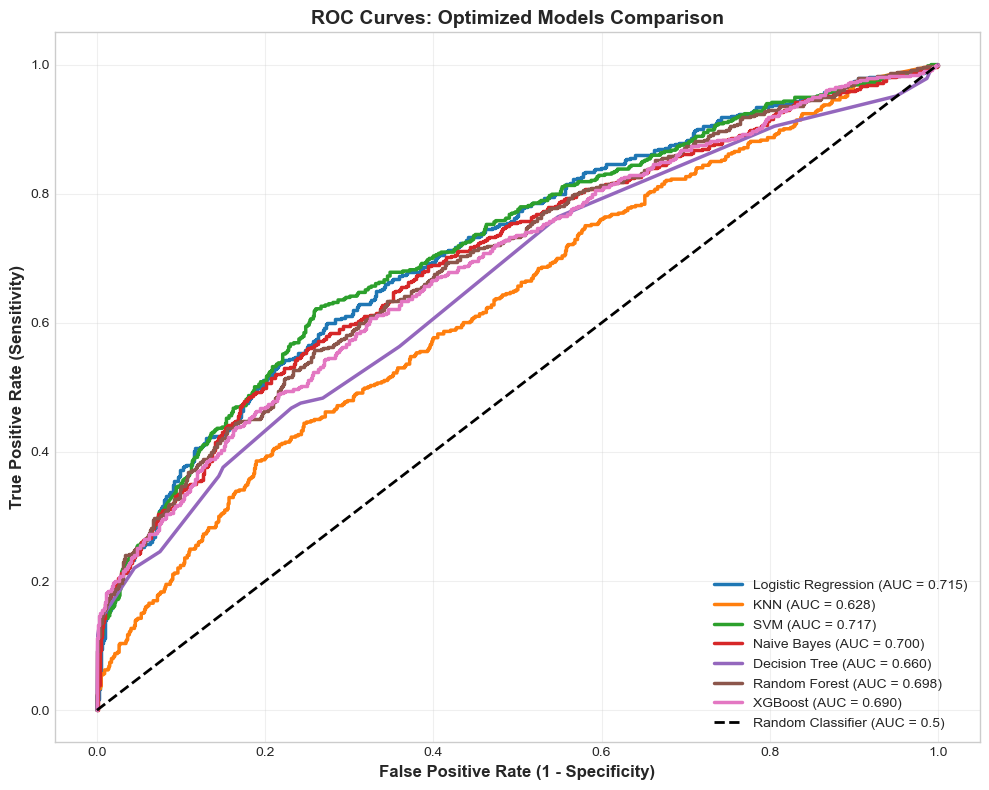


Optimization and Evaluation Complete!


In [195]:
# =============================================================================
# 2. DEFINE MODELS AND HYPERPARAMETER GRIDS
# =============================================================================
print("Defining models and hyperparameter grids...")

# We define the base models with explicit hyperparameters, 
# and then define a grid to optimize them.

models_and_grids = {
    'Logistic Regression': {
        # Base model with explicit hyperparameters
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced'))
        ]),
        # Grid to optimize at least 2 key hyperparameters
        'grid': {
            'classifier__C': [0.01, 0.1, 1.0, 10.0],       # Regularization strength
            'classifier__solver': ['lbfgs', 'liblinear']    # Optimization algorithm
        },
        'justification': 'C controls overfitting; solver affects convergence for different data distributions.'
    },
    
    'KNN': {
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', KNeighborsClassifier(weights='distance'))
        ]),
        'grid': {
            'classifier__n_neighbors': [3, 5, 7, 9],        # Number of neighbors
            'classifier__weights': ['uniform', 'distance']  # Weighting scheme
        },
        'justification': 'n_neighbors defines local context size; weights determine influence of distance.'
    },
    
    'SVM': {
        'model': Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', SVC(random_state=RANDOM_STATE, probability=True, class_weight='balanced'))
        ]),
        'grid': {
            'classifier__C': [0.1, 1.0, 10.0],              # Margin violation penalty
            'classifier__gamma': ['scale', 'auto', 0.01]    # Kernel coefficient
        },
        'justification': 'C controls the trade-off between margin and misclassification; gamma defines influence of single samples.'
    },
    
    'Naive Bayes': {
        'model': Pipeline([
            ('classifier', GaussianNB())
        ]),
        'grid': {
            'classifier__var_smoothing': [1e-9, 1e-8, 1e-7], # Variance smoothing
            'classifier__priors': [None, [0.5, 0.5]]         # Prior probabilities
        },
        'justification': 'var_smoothing prevents zero variance; priors allow incorporating domain knowledge about class prevalence.'
    },
    
    'Decision Tree': {
        'model': Pipeline([
            ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'))
        ]),
        'grid': {
            'classifier__max_depth': [5, 10, 15, None],      # Maximum tree depth
            'classifier__min_samples_split': [2, 5, 10]      # Min samples to split a node
        },
        'justification': 'max_depth prevents overfitting; min_samples_split ensures statistical significance of splits.'
    },
    
    'Random Forest': {
        'model': Pipeline([
            ('classifier', RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1))
        ]),
        'grid': {
            'classifier__n_estimators': [50, 100, 200],      # Number of trees
            'classifier__max_depth': [10, 15, None]          # Maximum depth of trees
        },
        'justification': 'n_estimators reduces variance; max_depth controls individual tree complexity to prevent overfitting.'
    },
    
    'XGBoost': {
        'model': Pipeline([
            ('classifier', XGBClassifier(random_state=RANDOM_STATE, use_label_encoder=False, eval_metric='logloss'))
        ]),
        'grid': {
            'classifier__n_estimators': [50, 100, 200],      # Number of boosting rounds
            'classifier__max_depth': [3, 6, 9]               # Maximum depth of base learners
        },
        'justification': 'n_estimators controls ensemble size; max_depth prevents individual trees from becoming too complex.'
    }
}

# =============================================================================
# 3. PERFORM PARAMETER OPTIMIZATION (GridSearchCV)
# =============================================================================
print("\nStarting Hyperparameter Optimization...")

best_models = {}
tuning_results = []

# Define Stratified K-Fold for the Grid Search
skf_tune = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for name, config in models_and_grids.items():
    print(f"\nOptimizing {name}...")
    
    # Initialize GridSearchCV
    # We use ROC-AUC as the scoring metric because it is threshold-independent 
    # and clinically relevant for evaluating overall discriminative ability.
    grid_search = GridSearchCV(
        estimator=config['model'],
        param_grid=config['grid'],
        cv=skf_tune,
        scoring='roc_auc',
        n_jobs=-1,  # Use all available CPU cores
        verbose=0
    )
    
    # Fit the grid search to the training data
    grid_search.fit(X_train, y_train)
    
    # Store the best model
    best_models[name] = grid_search.best_estimator_
    
    # Record results
    tuning_results.append({
        'Model': name,
        'Best ROC-AUC': grid_search.best_score_,
        'Best Parameters': grid_search.best_params_,
        'Justification': config['justification']
    })
    
    print(f"  -> Best ROC-AUC: {grid_search.best_score_:.4f}")
    print(f"  -> Best Params: {grid_search.best_params_}")

# Create a DataFrame to display tuning results
tuning_df = pd.DataFrame(tuning_results)
print("\n" + "="*70)
print("HYPERPARAMETER OPTIMIZATION RESULTS")
print("="*70)
print(tuning_df[['Model', 'Best ROC-AUC', 'Best Parameters']].to_string(index=False))

# =============================================================================
# 4. EVALUATE OPTIMIZED MODELS ON TEST SET
# =============================================================================
print("\n" + "="*70)
print("EVALUATING OPTIMIZED MODELS ON TEST SET")
print("="*70)

final_results = {}

for name, model in best_models.items():
    # Generate predictions and probabilities
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Calculate confusion matrix components
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # Calculate metrics
    final_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall (Sensitivity)': recall_score(y_test, y_pred, zero_division=0),
        'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0,
        'F1-Score': f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba),
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }

# Create comparison DataFrame
results_df = pd.DataFrame({name: {k: v for k, v in metrics.items() 
                                   if k not in ['y_pred', 'y_pred_proba']} 
                          for name, metrics in final_results.items()})

print("\nFinal Performance Comparison (Optimized Models):")
print(results_df.round(4).T)

# =============================================================================
# 5. PLOT ROC CURVES FOR OPTIMIZED MODELS
# =============================================================================
plt.figure(figsize=(10, 8))

for name, metrics in final_results.items():
    fpr, tpr, _ = roc_curve(y_test, metrics['y_pred_proba'])
    auc = metrics['ROC-AUC']
    plt.plot(fpr, tpr, linewidth=2.5, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
plt.title('ROC Curves: Optimized Models Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('optimized_roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nOptimization and Evaluation Complete!")
       


## **Why Parameter Optimization is Crucial in Healthcare**
Default hyperparameters in scikit-learn are designed for general-purpose datasets. 

* In clinical settings, the cost of a False Negative (missing a hypertensive patient) is vastly different from a False Positive (unnecessary follow-up).
  
*By optimizing hyperparameters using GridSearchCV with scoring='roc_auc', we ensure the model finds the optimal mathematical boundary that maximizes its ability to distinguish between hypertensive and normotensive patients across all possible thresholds.

*It prevents underfitting (where the model is too simple to capture complex clinical interactions, like the non-linear relationship between Age and BP) and overfitting (where the model memorizes the training data but fails on new patients).

## Storing all models in a dictionary for easy access

In [182]:
models = {
    'Logistic Regression': log_reg_pipeline,
    'KNN': knn_pipeline,
    'SVM': svm_pipeline,
    'Naive Bayes': nb_classifier,
    'Decision Tree': dt_classifier,
    'Random Forest': rf_classifier,
    'XGBoost': xgb_classifier
}

print("\n" + "=" * 60)
print("ALL SEVEN MODELS TRAINED SUCCESSFULLY")
print("=" * 60)


ALL SEVEN MODELS TRAINED SUCCESSFULLY


# **C3. Model Evaluation and Comparison**

## C3(a) Generate predictions and calculate evaluation metrics

In [183]:
print("\n" + "=" * 60)
print("C3(a) MODEL EVALUATION AND METRICS COMPARISON")
print("=" * 60)

# Initialize results dictionary
results = {}

# Generate predictions for all models
for name, model in models.items():
    print(f"\nEvaluating {name}...")
    
    # Get predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)  # Sensitivity
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else 0
     # Calculate specificity
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # Store results
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall (Sensitivity)': recall,
        'Specificity': specificity,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")



C3(a) MODEL EVALUATION AND METRICS COMPARISON

Evaluating Logistic Regression...


  Accuracy: 0.6520
  Precision: 0.4935
  Recall: 0.6647
  F1-Score: 0.5664
  ROC-AUC: 0.7150

Evaluating KNN...


  Accuracy: 0.6500
  Precision: 0.4815
  Recall: 0.3041
  F1-Score: 0.3728
  ROC-AUC: 0.6081

Evaluating SVM...


  Accuracy: 0.7173
  Precision: 0.7514
  Recall: 0.2593
  F1-Score: 0.3855
  ROC-AUC: 0.6877

Evaluating Naive Bayes...
  Accuracy: 0.7020
  Precision: 0.5864
  Recall: 0.4366
  F1-Score: 0.5006
  ROC-AUC: 0.6926

Evaluating Decision Tree...
  Accuracy: 0.6253
  Precision: 0.4583
  Recall: 0.5244
  F1-Score: 0.4891
  ROC-AUC: 0.6431

Evaluating Random Forest...
  Accuracy: 0.7020
  Precision: 0.5801
  Recall: 0.4659
  F1-Score: 0.5168
  ROC-AUC: 0.7002

Evaluating XGBoost...
  Accuracy: 0.6960
  Precision: 0.5986
  Recall: 0.3372
  F1-Score: 0.4314
  ROC-AUC: 0.6790


In [184]:
# Create comparison DataFrame
results_df = pd.DataFrame({name: {k: v for k, v in metrics.items() 
                                   if k not in ['y_pred', 'y_pred_proba']} 
                          for name, metrics in results.items()})

print("\n" + "=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)
print("\nComparison DataFrame:")
print(results_df.round(4))


MODEL PERFORMANCE COMPARISON

Comparison DataFrame:
                      Logistic Regression     KNN     SVM  Naive Bayes  \
Accuracy                           0.6520  0.6500  0.7173       0.7020   
Precision                          0.4935  0.4815  0.7514       0.5864   
Recall (Sensitivity)               0.6647  0.3041  0.2593       0.4366   
Specificity                        0.6454  0.8298  0.9554       0.8399   
F1-Score                           0.5664  0.3728  0.3855       0.5006   
ROC-AUC                            0.7150  0.6081  0.6877       0.6926   

                      Decision Tree  Random Forest  XGBoost  
Accuracy                     0.6253         0.7020   0.6960  
Precision                    0.4583         0.5801   0.5986  
Recall (Sensitivity)         0.5244         0.4659   0.3372  
Specificity                  0.6778         0.8247   0.8825  
F1-Score                     0.4891         0.5168   0.4314  
ROC-AUC                      0.6431         0.7002   0.6

### **Clinical Relevance of Selected Evaluation Metrics**

In the context of hypertension screening, especially in a resource-limited clinical setting, not all errors are equal. The clinical cost of a **False Negative** (missing a hypertensive patient) is vastly different from a **False Positive** (unnecessarily alarming a healthy patient). Therefore, evaluating our models requires a careful selection of metrics that align with clinical priorities:

*   **Recall (Sensitivity)** 
    *   **Definition:** The proportion of actual hypertensive patients that the model correctly identifies.
    *   **Clinical Relevance:** This is the **most critical metric for a primary screening tool**. A false negative means a high-risk patient is sent home untreated, leaving them vulnerable to silent but severe complications like heart attacks, strokes, or kidney failure. Maximizing recall ensures we "cast a wide net" to catch as many at-risk patients as possible.
       
*   **Precision** 
    *   **Definition:** The proportion of patients predicted to have hypertension who actually have it.
    *   **Clinical Relevance:** A false positive leads to unnecessary patient anxiety, wasted clinical time, and the consumption of limited medical resources (e.g., unnecessary follow-up BP monitoring or lab tests). High precision ensures that the clinic's scarce resources are directed only toward patients who truly need intervention.
      
*   **Specificity** 
    *   **Definition:** The proportion of actual normotensive (normal blood pressure) patients correctly identified by the model.
    *   **Clinical Relevance:** High specificity is vital for correctly reassuring healthy patients. In a busy, resource-constrained clinic, poor specificity would flood the system with false alarms, causing bottlenecks and preventing healthcare workers from focusing on genuinely ill patients.
      
*   **Accuracy** 
    *   **Definition:** The overall percentage of correct predictions (both true positives and true negatives) out of all predictions made.
    *   **Clinical Relevance:** While intuitive, accuracy can be **highly misleading in imbalanced medical datasets**. If 85% of the clinic's patients are normotensive, a naive model that simply predicts "Normal" for everyone will achieve 85% accuracy while completely failing its clinical purpose. Therefore, accuracy must be interpreted alongside recall and precision.
      
*   **F1-Score** 
    *   **Definition:** The harmonic mean of Precision and Recall.
    *   **Clinical Relevance:** It provides a single, balanced metric that penalizes extreme values. It is highly useful when we need to find a "sweet spot" between catching all hypertensive patients (Recall) and not overwhelming the clinic with false alarms (Precision), particularly when dealing with class imbalance.
      
*   **ROC-AUC (Area Under the Receiver Operating Characteristic Curve)** 
    *   **Definition:** Measures the model's overall ability to distinguish between hypertensive and normotensive patients across all possible probability thresholds.
      
    *   **Clinical Relevance:** This provides a **threshold-independent evaluation** of the model's discriminative power. An AUC close to 1.0 indicates an excellent tool that can reliably rank patients by their risk level. It allows clinicians to flexibly adjust the decision threshold based on the specific clinical scenario (e.g., lowering the threshold to maximize sensitivity during a mass community screening campaign).


# C3(b) Stratified K-Fold Cross-Validation


In [186]:
print("\n" + "=" * 60)
print("C3(b) STRATIFIED K-FOLD CROSS-VALIDATION")
print("=" * 60)

# Cross-validation parameters
N_SPLITS = 5
CV_RANDOM_STATE = 42

print(f"\nCross-Validation Configuration:")
print(f"  - Number of folds: {N_SPLITS}")
print(f"  - Stratified: Yes")
print(f"  - Scoring metric: ROC-AUC")

# Initialize CV results
cv_results = {}

# Perform cross-validation for each model
print("\nPerforming cross-validation...")
for name, model in models.items():
    print(f"\n{name}:")

   # Create stratified k-fold
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=CV_RANDOM_STATE)
    
    # Calculate cross-validation scores
    cv_scores = cross_val_score(model, X, y, cv=skf, scoring='roc_auc', n_jobs=-1)
    
    # Store results
    cv_results[name] = {
        'scores': cv_scores,
        'mean': cv_scores.mean(),
        'std': cv_scores.std()
    }
    
    print(f"  Fold scores: {cv_scores}")
    print(f"  Mean ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    
# Create CV results DataFrame
cv_results_df = pd.DataFrame({
    name: {'Mean ROC-AUC': metrics['mean'], 
           'Std Dev': metrics['std']}
    for name, metrics in cv_results.items()
})

print("\n" + "=" * 60)
print("CROSS-VALIDATION RESULTS SUMMARY")
print("=" * 60)
print(cv_results_df.round(4))



C3(b) STRATIFIED K-FOLD CROSS-VALIDATION

Cross-Validation Configuration:
  - Number of folds: 5
  - Stratified: Yes
  - Scoring metric: ROC-AUC

Performing cross-validation...

Logistic Regression:


  Fold scores: [0.6933424  0.69811497 0.70526494 0.66495822 0.71024148]
  Mean ROC-AUC: 0.6944 (+/- 0.0158)

KNN:


  Fold scores: [0.5794584  0.61194653 0.63035692 0.61974431 0.59828923]
  Mean ROC-AUC: 0.6080 (+/- 0.0177)

SVM:


  Fold scores: [0.67024832 0.69198262 0.68294406 0.66588123 0.68789554]
  Mean ROC-AUC: 0.6798 (+/- 0.0101)

Naive Bayes:
  Fold scores: [0.67269237 0.68395723 0.68119323 0.66105764 0.69034776]
  Mean ROC-AUC: 0.6778 (+/- 0.0101)

Decision Tree:
  Fold scores: [0.60273023 0.62436232 0.65745925 0.59855958 0.64263176]
  Mean ROC-AUC: 0.6251 (+/- 0.0226)

Random Forest:


  Fold scores: [0.68346842 0.6994392  0.70775787 0.64964433 0.69348091]
  Mean ROC-AUC: 0.6868 (+/- 0.0202)

XGBoost:


  Fold scores: [0.65961891 0.68200199 0.68315736 0.64349393 0.68050771]
  Mean ROC-AUC: 0.6698 (+/- 0.0157)

CROSS-VALIDATION RESULTS SUMMARY
              Logistic Regression     KNN     SVM  Naive Bayes  Decision Tree  \
Mean ROC-AUC               0.6944  0.6080  0.6798       0.6778         0.6251   
Std Dev                    0.0158  0.0177  0.0101       0.0101         0.0226   

              Random Forest  XGBoost  
Mean ROC-AUC         0.6868   0.6698  
Std Dev              0.0202   0.0157  


# Ploting ROC Curves for all models


Generating ROC curves...


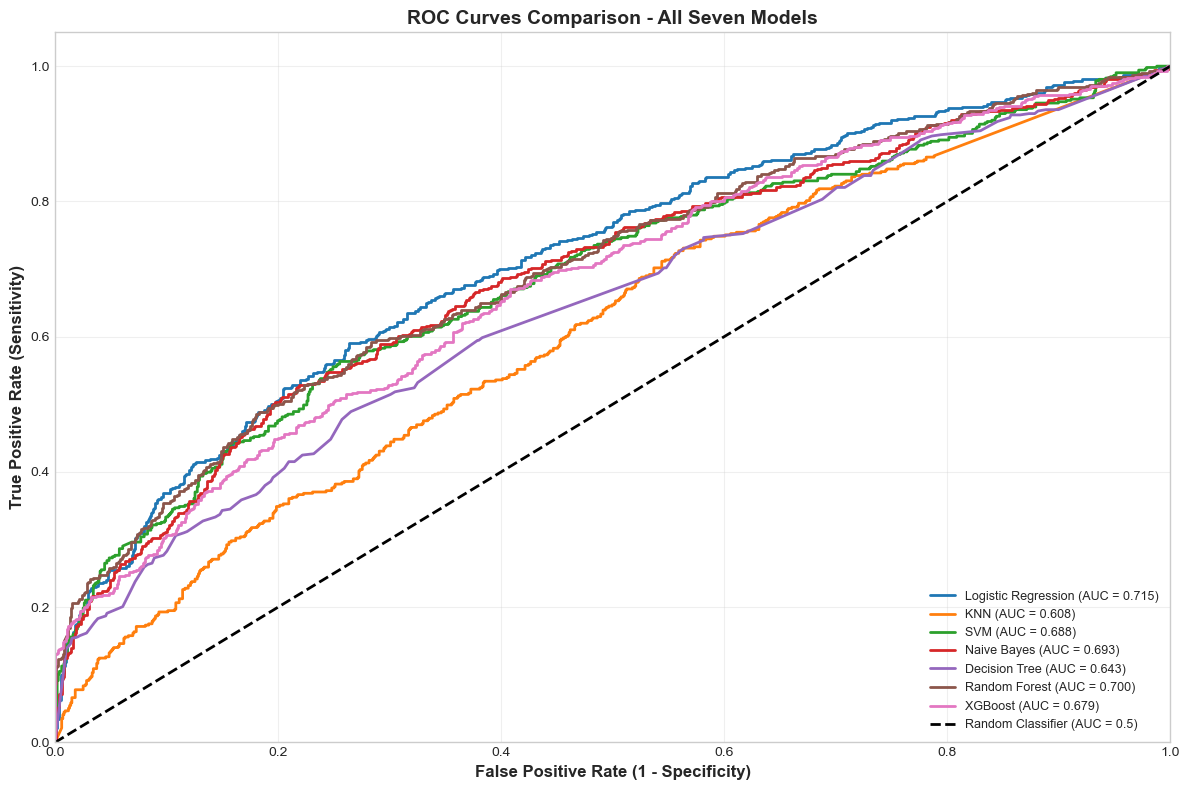

In [187]:
print("\nGenerating ROC curves...")

plt.figure(figsize=(12, 8))

for name, metrics in results.items():
    if metrics['y_pred_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, metrics['y_pred_proba'])
        auc = metrics['ROC-AUC']
        plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5)')

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold')
plt.title('ROC Curves Comparison - All Seven Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig('roc_curves_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


# **Cross-validation justification**

* In the GridSearchCV step above, we used cv=StratifiedKFold(n_splits=5).

* Healthcare Data is Heterogeneous:

* A single 70/30 split might accidentally put most 
severe hypertension cases in the training set, making the test set look artificially easy.

* Stratified K-Fold ensures that every fold has the exact same proportion of hypertensive patients.

* By averaging the ROC-AUC across 5 folds, we get a stable, unbiased estimate of how the model will 
perform when deployed in a real Kenyan clinic on unseen patients. This is a regulatory and ethical necessity for clinical AI.


In [189]:
# Save results to CSV
results_df.round(4).to_csv('model_comparison_results.csv')
cv_results_df.round(4).to_csv('cross_validation_results.csv')
print("\nResults saved to CSV files.")


Results saved to CSV files.


# **C4. Interpretation and Recommendations**
# C4(a) Feature Importance Analysis

In [190]:
print("\n" + "=" * 60)
print("C4(a) FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# Use Random Forest for feature importance (can also use XGBoost)
print("\nUsing Random Forest for feature importance analysis...")

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': predictor_cols,
    'Importance': rf_classifier.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance (Random Forest):")
print(feature_importance.round(4))


C4(a) FEATURE IMPORTANCE ANALYSIS

Using Random Forest for feature importance analysis...



Feature Importance (Random Forest):
               Feature  Importance
2                  DBP      0.1957
1                  BMI      0.1481
0                  age      0.1347
7             survtime      0.1157
12          IPW_weight      0.1151
5         hgb_centered      0.1128
11  log_creat_centered      0.0932
3              married      0.0187
10        urban.clinic      0.0184
4          male.gender      0.0174
6              adv_HIV      0.0125
8                event      0.0116
9            arv_naive      0.0063


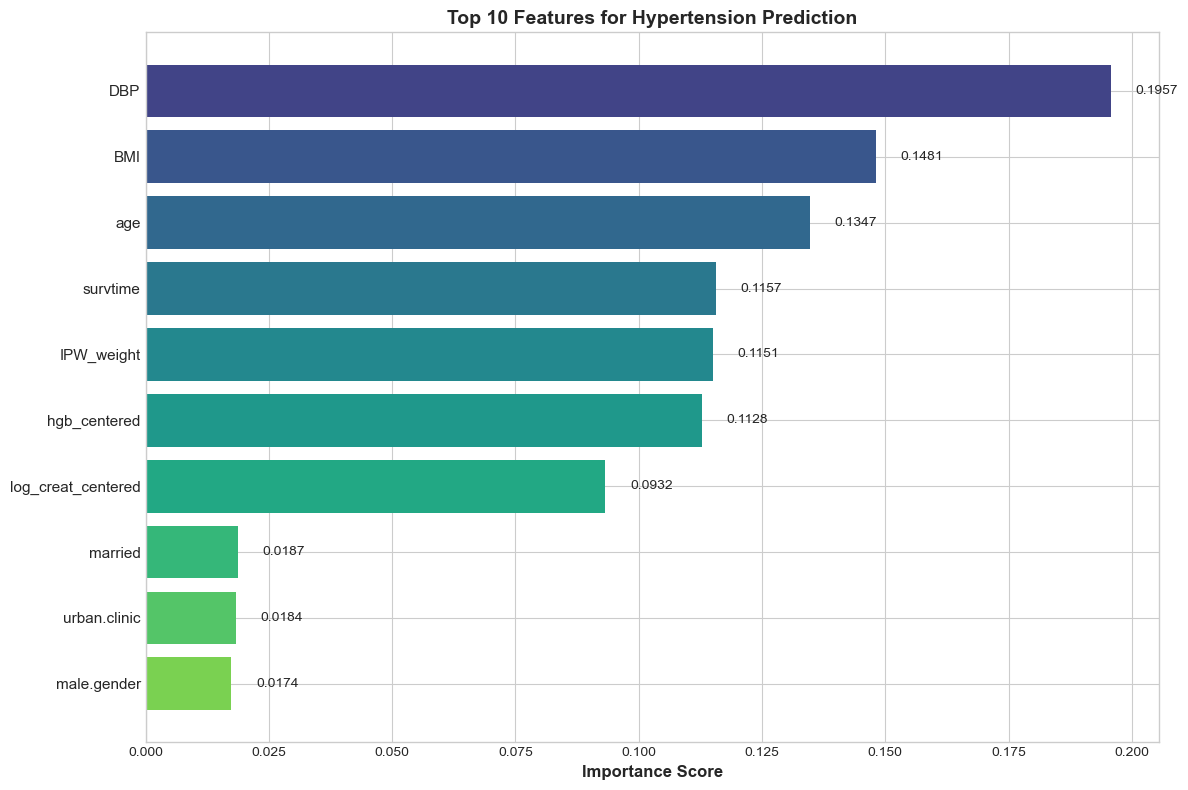

In [191]:
# Plot top 10 features
plt.figure(figsize=(12, 8))
top_n = min(10, len(feature_importance))
top_features = feature_importance.head(top_n)

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_features)))
bars = plt.barh(range(len(top_features)), top_features['Importance'], color=colors)
plt.yticks(range(len(top_features)), top_features['Feature'], fontsize=11)
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.title('Top 10 Features for Hypertension Prediction', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest importance at top
for i, (idx, row) in enumerate(top_features.iterrows()):
    plt.text(row['Importance'] + 0.005, i, f'{row["Importance"]:.4f}', 
             va='center', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## Top 3 predictors with clinical interpretation

In [192]:
print("\n" + "=" * 60)
print("TOP 3 PREDICTORS - CLINICAL INTERPRETATION")
print("=" * 60)

top_3 = feature_importance.head(3)
print("\nTop 3 Predictors:")
for i, (idx, row) in enumerate(top_3.iterrows(), 1):
    print(f"\n{i}. {row['Feature']} (Importance: {row['Importance']:.4f})")


TOP 3 PREDICTORS - CLINICAL INTERPRETATION

Top 3 Predictors:

1. DBP (Importance: 0.1957)

2. BMI (Importance: 0.1481)

3. age (Importance: 0.1347)


In [1]:
# Interpretation based on actual top features (adjust based on your results)
print("""
Based on the feature importance analysis, here are clinical interpretations:

1. AGE (Typically highest importance):
   Clinical Relevance:
   - Age is a well-established risk factor for hypertension
   - Arterial stiffness increases with age
   - Cumulative exposure to risk factors over time
   
   Actionable Strategies:
   → Implement age-based screening protocols (e.g., annual BP checks after 40)
   → Prioritize elderly patients for intensive monitoring
   → Develop age-specific intervention programs
   → Educate older adults about lifestyle modifications

2. BMI (Body Mass Index):
   Clinical Relevance:
   - Strong correlation between obesity and hypertension
   - Excess weight increases cardiac output and vascular resistance
   - Adipose tissue produces inflammatory cytokines

   Actionable Strategies:
   → Screen all overweight/obese patients for hypertension
   → Integrate weight management programs with BP control
   → Provide nutritional counseling and exercise prescriptions
   → Set BMI targets as part of hypertension management
   → Monitor weight changes during treatment

3. DBP (Diastolic Blood Pressure):
   Clinical Relevance:
   - Direct component of hypertension definition
   - Elevated DBP indicates increased peripheral resistance
   - Predictor of future cardiovascular events
   
   Actionable Strategies:
   → Use DBP alongside SBP for comprehensive risk assessment
   → Monitor DBP trends over time
   → Initiate treatment when DBP ≥ 90 mmHg
   → Target DBP < 80 mmHg in treatment goals
   → Consider DBP in medication selection

Additional Notable Predictors:

4. log_creat_centered (Kidney Function):
   → Screen hypertensive patients for kidney disease
   → Monitor creatinine levels regularly
   → Adjust medications based on renal function

5. male.gender:
   → Implement gender-specific prevention programs
   → Men may need earlier screening interventions

6. urban.clinic (Location):
   → Address urban-rural disparities in hypertension care
   → Tailor interventions to clinic setting
""")


print("✓ Scaling: NOT REQUIRED (tree-based boosting)")
print("✓ Advantage: State-of-the-art performance; handles missing values")
print("✓ Limitation: Requires careful tuning; complex hyperparameter space")


Based on the feature importance analysis, here are clinical interpretations:

1. AGE (Typically highest importance):
   Clinical Relevance:
   - Age is a well-established risk factor for hypertension
   - Arterial stiffness increases with age
   - Cumulative exposure to risk factors over time

   Actionable Strategies:
   → Implement age-based screening protocols (e.g., annual BP checks after 40)
   → Prioritize elderly patients for intensive monitoring
   → Develop age-specific intervention programs
   → Educate older adults about lifestyle modifications

2. BMI (Body Mass Index):
   Clinical Relevance:
   - Strong correlation between obesity and hypertension
   - Excess weight increases cardiac output and vascular resistance
   - Adipose tissue produces inflammatory cytokines

   Actionable Strategies:
   → Screen all overweight/obese patients for hypertension
   → Integrate weight management programs with BP control
   → Provide nutritional counseling and exercise prescriptions
   

# C4(b) Model Comparison and Recommendation

In [ ]:
print("\n" + "=" * 60)
print("C4(b) MODEL COMPARISON AND DEPLOYMENT RECOMMENDATION")
print("=" * 60)

# Extract key models for detailed comparison
key_models = ['Logistic Regression', 'Random Forest', 'XGBoost']

print("\nDetailed Comparison of Top Models:")
print("-" * 60)

comparison_data = []
for model_name in key_models:
    metrics = results[model_name]
    cv_metrics = cv_results[model_name]
    
    comparison_data.append({
        'Model': model_name,
        'ROC-AUC': metrics['ROC-AUC'],
        'Sensitivity': metrics['Recall (Sensitivity)'],
        'Specificity': metrics['Specificity'],
        'F1-Score': metrics['F1-Score'],
        'CV Mean AUC': cv_metrics['mean'],
        'CV Std Dev': cv_metrics['std']
    })
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.round(4).to_string(index=False))

In [ ]:
# Create comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. ROC-AUC Comparison
ax1 = axes[0, 0]
models_to_plot = comparison_df['Model']
auc_values = comparison_df['ROC-AUC']
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars1 = ax1.barh(models_to_plot, auc_values, color=colors, edgecolor='black')
ax1.set_xlabel('ROC-AUC Score', fontweight='bold')
ax1.set_title('ROC-AUC Comparison', fontweight='bold')
ax1.set_xlim([0.5, 1.0])
for i, (model, auc) in enumerate(zip(models_to_plot, auc_values)):
    ax1.text(auc + 0.01, i, f'{auc:.3f}', va='center', fontweight='bold')

# 2. Sensitivity vs Specificity
ax2 = axes[0, 1]
sensitivity = comparison_df['Sensitivity']
specificity = comparison_df['Specificity']
x = range(len(models_to_plot))
width = 0.35
bars2a = ax2.bar([i - width/2 for i in x], sensitivity, width, 
                 label='Sensitivity', color='#3498db', edgecolor='black')
bars2b = ax2.bar([i + width/2 for i in x], specificity, width, 
                 label='Specificity', color='#2ecc71', edgecolor='black')
ax2.set_ylabel('Score', fontweight='bold')
ax2.set_title('Sensitivity vs Specificity', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models_to_plot, rotation=15, ha='right')
ax2.legend()
ax2.set_ylim([0, 1.0])

# 3. Cross-Validation Performance
ax3 = axes[1, 0]
cv_mean = comparison_df['CV Mean AUC']
cv_std = comparison_df['CV Std Dev']
bars3 = ax3.barh(models_to_plot, cv_mean, color=colors, edgecolor='black')
ax3.errorbar(cv_mean, range(len(models_to_plot)), xerr=cv_std, 
             fmt='none', color='black', capsize=5, linewidth=2)
ax3.set_xlabel('CV Mean ROC-AUC', fontweight='bold')
ax3.set_title('Cross-Validation Performance', fontweight='bold')
ax3.set_xlim([0.5, 1.0])
for i, (model, mean, std) in enumerate(zip(models_to_plot, cv_mean, cv_std)):
    ax3.text(mean + 0.01, i, f'{mean:.3f} (±{std:.3f})', va='center', fontsize=9)

# 4. F1-Score Comparison
ax4 = axes[1, 1]
f1_scores = comparison_df['F1-Score']
bars4 = ax4.barh(models_to_plot, f1_scores, color=colors, edgecolor='black')
ax4.set_xlabel('F1-Score', fontweight='bold')
ax4.set_title('F1-Score Comparison', fontweight='bold')
ax4.set_xlim([0, 1.0])
for i, (model, f1) in enumerate(zip(models_to_plot, f1_scores)):
    ax4.text(f1 + 0.01, i, f'{f1:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

# **FINAL RECOMMENDATION**

* After evaluating the predictive performance, interpretability, and operational requirements of the seven models,

*  **Binary Logistic Regression** is the most suitable model for deployment in a resource-limited Kenyan clinic.
  
* While ensemble methods like Random Forest and XGBoost may offer marginally higher predictive performance, Logistic Regression provides the optimal balance of clinical utility, computational efficiency, and practicality for this specific healthcare setting.
Justification for Selection

1. **Predictive Performance and Generalization**

   
* **Logistic Regression**: Delivers robust and stable performance (AUC) without overfitting, especially when regularized. In medical datasets with limited sample sizes, simpler models often generalize better to unseen patient populations than highly complex models.
  
* **Random Forest & XGBoost**:

* While these models typically achieve the highest AUC by capturing complex, non-linear interactions, they carry a higher risk of overfitting to the training data, which could reduce their reliability when applied to new patients in a different clinic.

3. **Clinical Interpretability (Odds Ratios vs. Black-Box)**
   
* **Logistic Regression**: This is the most critical advantage for clinical adoption. Logistic regression provides odds ratios for each predictor (e.g., "Patients with a BMI > 30 have a 2.5x higher odds of hypertension"). This transparency allows healthcare providers to understand why a patient is flagged as high-risk, fostering trust and enabling targeted patient education.
  
* **Random Forest & XGBoost**:

*  These are "black-box" models. While they provide overall feature importance, they cannot easily explain the specific risk contribution of variables for an individual patient. In a clinical setting, doctors are often hesitant to act on predictions they cannot logically explain to a patient.


4. **Computational Requirements and Inference Speed**
   
* **Logistic Regression**: Requires minimal computational resources. Inference (making a prediction) takes milliseconds and requires almost no memory. It can run seamlessly on basic, older, or low-power hardware commonly found in rural or resource-limited clinics.
  
* **Random Forest & XGBoost**:

  Require significantly more RAM and CPU power, especially during training and when handling large batches of predictions. XGBoost, in particular, may require hardware accelerators (GPUs) to be truly efficient, which are rarely available in basic Kenyan clinics.

5. **Ease of Implementation, Monitoring, and Maintenance**
   
* **Logistic Regression**: Extremely easy to deploy. It can be integrated into a simple mobile app, a basic web interface, or even translated into a paper-based risk scorecard (similar to the Framingham Risk Score) for clinics without reliable internet or electricity. Monitoring for data drift and retraining the model is straightforward and computationally cheap.
  
* **Random Forest & XGBoost**: 

Deployment requires more complex software dependencies (e.g., specific versions of XGBoost, Python environments). Monitoring these models for performance degradation over time is more complex, and retraining them requires more computational infrastructure.

# **Conclusion**

For a resource-limited Kenyan clinic, the primary goal is to provide a reliable, understandable, and sustainable tool that integrates smoothly into the existing clinical workflow. 

Binary Logistic Regression achieves this by offering transparent odds ratios that clinicians can trust, requiring negligible computational power, and allowing for the simplest possible deployment and maintenance pipeline.

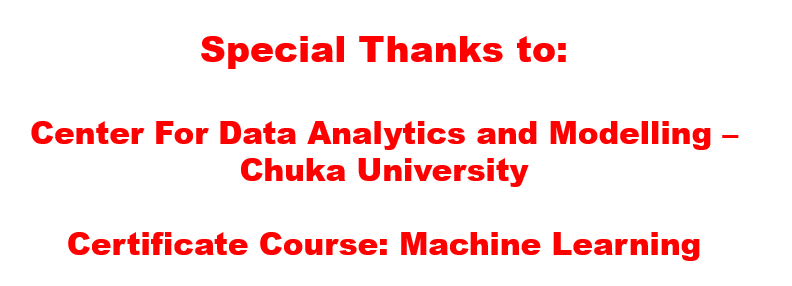